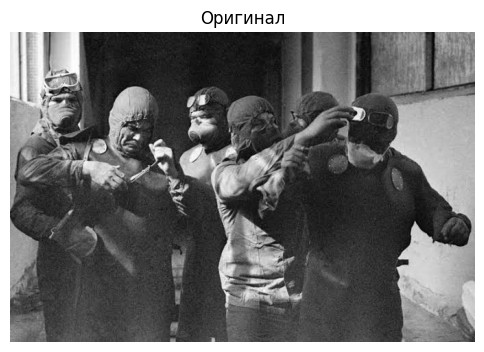

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Загрузка изображения и конвертация в градации серого
image_path = 'people_me.jpg'
image = cv2.imread(image_path)

if image is None:
    print("error")
else:
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Вывод оригинального изображения
    plt.figure(figsize=(6, 6))
    plt.imshow(image_gray, cmap="gray")
    plt.title("Оригинал")
    plt.axis('off')
    plt.show()

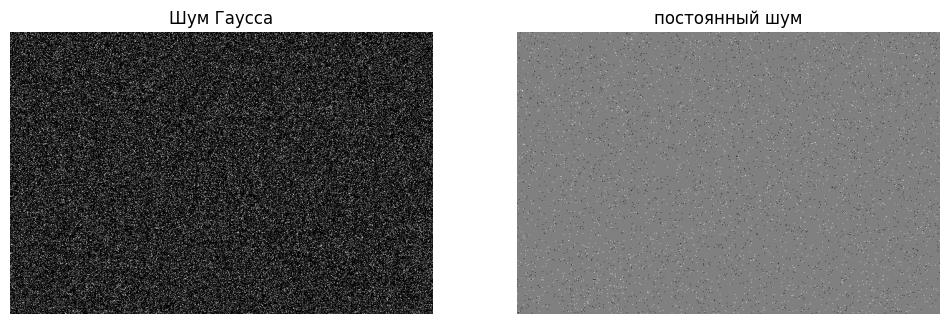

In [10]:
#  1 Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

# 2 Постоянный шум
noise = np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

# Создаем фон для наглядного вывода текстуры "соли и перца"
bg_image_sp = np.ones(image_gray.shape, np.uint8) * 128
bg_image_sp[zeros_pixel] = 0
bg_image_sp[ones_pixel] = 255

# Вывод чистого шума
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noise_gauss, cmap="gray")
plt.title("Шум Гаусса")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bg_image_sp, cmap="gray")
plt.title("постоянный шум")
plt.axis('off')
plt.show()

In [12]:
# Накладываем шум на фотографию
image_noise_gauss = cv2.add(image_gray, noise_gauss)

image_noise_sp = image_gray.copy()
image_noise_sp[zeros_pixel] = 0
image_noise_sp[ones_pixel] = 255

# Словари для сохранения результатов
results_gauss = {}
results_sp = {}

# Фильтр Гаусса
results_gauss['Gaussian'] = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
results_sp['Gaussian'] = cv2.GaussianBlur(image_noise_sp, (5, 5), 0)

# Медианный фильтр
results_gauss['Median'] = cv2.medianBlur(image_noise_gauss, 5)
results_sp['Median'] = cv2.medianBlur(image_noise_sp, 5)

# Билатеральный фильтр (d=9, сигмы=75)
results_gauss['Bilateral'] = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
results_sp['Bilateral'] = cv2.bilateralFilter(image_noise_sp, 9, 75, 75)

# Фильтр нелокальных средних NLM (h=30)
results_gauss['NLM'] = cv2.fastNlMeansDenoising(image_noise_gauss, None, 30, 7, 21)
results_sp['NLM'] = cv2.fastNlMeansDenoising(image_noise_sp, None, 30, 7, 21)

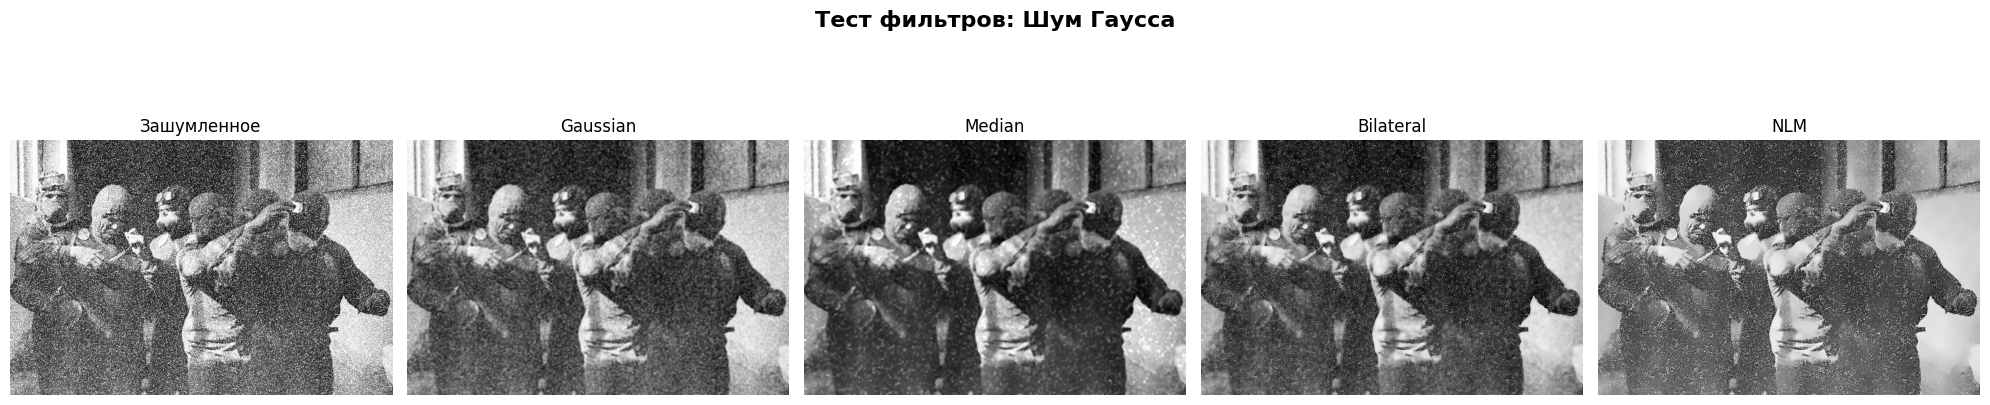

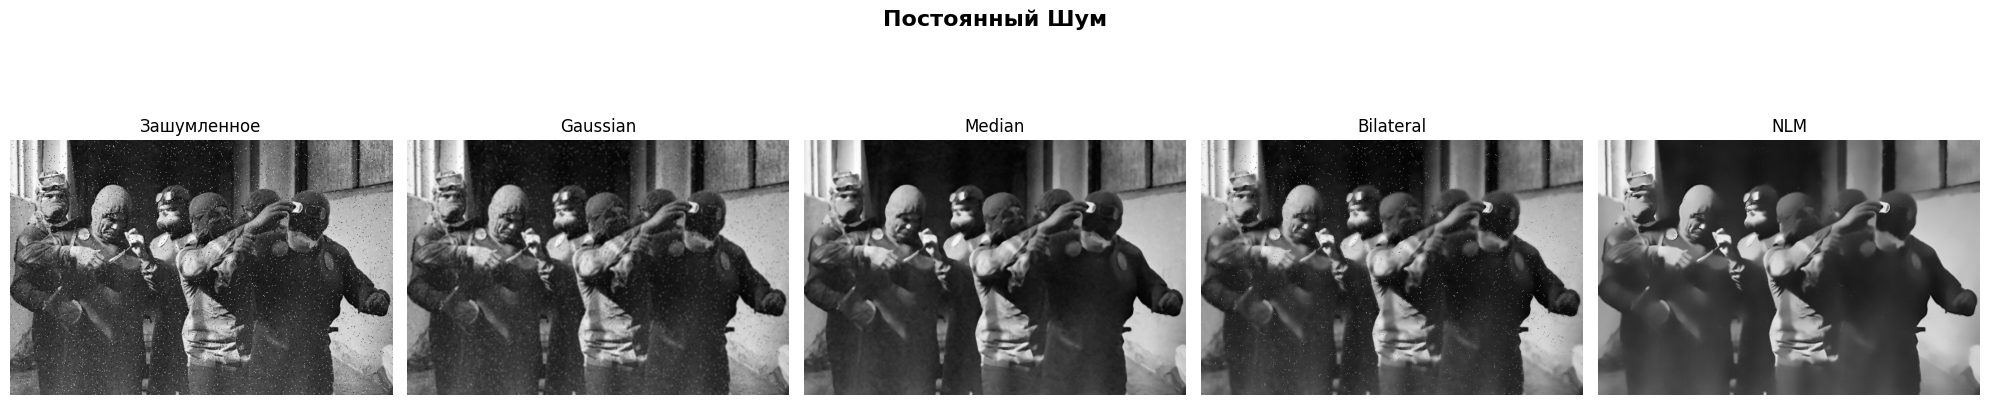

In [14]:
# Функция для отрисовки 5 картинок
def plot_results(original_noisy, results_dict, title_prefix):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(title_prefix, fontsize=16, fontweight='bold')

    # Исходное зашумленное
    axes[0].imshow(original_noisy, cmap='gray')
    axes[0].set_title('Зашумленное')
    axes[0].axis('off')

    # Отфильтрованные варианты
    for ax, (name, img) in zip(axes[1:], results_dict.items()):
        ax.imshow(img, cmap='gray')
        ax.set_title(name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Отрисовка
plot_results(image_noise_gauss, results_gauss, "Тест фильтров: Шум Гаусса")
plot_results(image_noise_sp, results_sp, "Постоянный Шум")

### Вывод по результатам фильтрации:

1. **Для постоянного шума:**
Лучший результат фильтрации показал **Медианный фильтр**. Он отлично удаляет черные и белые точки, сохраняя при этом резкость границ объектов изображения. Остальные фильтры лишь размывают точки, превращая их в пятна или оставляют такой же шум.

2. **Для шума Гаусса:**
Лучший результат показал **Медианный**, так как он отлично восстанавливает однородные участки текстуры. **Билатеральный фильтр** также хорош, поскольку, в отличие от Гауссовского, он сохраняет контуры объектов резкими при сглаживании шума.(на самом деле на каждой фотогрфии по-разному,это все индивидуально)